# K-Nearest Neighbors (KNN)

**Dataset:** Heart Disease (`cleaned_merged_heart_dataset.csv`)

This notebook follows the standard methodology:

1. Dataset Loading & Preview
2. Preprocessing Pipeline
3. Hyperparameter Tuning Log
4. Final Model Selection Leaderboard
5. Best Model Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')


## 1. Dataset Loading & Preview

Load the dataset and inspect the first few rows (mirroring the dataset preview at the top of each Excel sheet).


In [2]:
df = pd.read_csv('/content/cleaned_merged_heart_dataset.csv')
print(f"Dataset shape: {df.shape}")
display(df.head())

print("\nColumn information:")
df.info()


Dataset shape: (1888, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1888 entries, 0 to 1887
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1888 non-null   int64  
 1   sex       1888 non-null   int64  
 2   cp        1888 non-null   int64  
 3   trestbps  1888 non-null   int64  
 4   chol      1888 non-null   int64  
 5   fbs       1888 non-null   int64  
 6   restecg   1888 non-null   int64  
 7   thalachh  1888 non-null   int64  
 8   exang     1888 non-null   int64  
 9   oldpeak   1888 non-null   float64
 10  slope     1888 non-null   int64  
 11  ca        1888 non-null   int64  
 12  thal      1888 non-null   int64  
 13  target    1888 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 206.6 KB


## 2. Preprocessing Pipeline

A structured preprocessing pipeline, organised the same way as the Titanic sheet in the bake-off template. **Feature scaling is critical for KNN** — distance-based algorithms are extremely sensitive to feature magnitude.

### 1. Handling Missing Values (Imputation)
- **Numeric columns:** Use the **median** to avoid the influence of outliers.
- **Categorical columns:** Use the **mode** (most frequent value).

### 2. Feature Engineering / Selection
- Drop redundant text columns (`sex_text`, `thal_text`) since `sex` and `thal` are already numerical.
- Separate features (`X`) from target (`y`).

### 3. Categorical Encoding
- `sex` and `thal` are already label-encoded as numeric → no further encoding required.

### 4. Feature Scaling (Normalization) — **Mandatory for KNN**
- Apply **StandardScaler** so all features contribute equally to the distance metric.
- Without this step, large-magnitude features (e.g. `chol`, `thalach`) would dominate the neighbour search.
- Formula (per feature): `z = (x - mean) / std`


In [3]:
# 1. Handling Missing Values
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

for c in num_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].mode().iloc[0])

# 2. Feature Engineering / Selection
X = df.drop('target', axis=1)
y = df['target']

for col in ['sex_text', 'thal_text']:
    if col in X.columns:
        X = X.drop(col, axis=1)

# 3. Categorical Encoding — already numeric, nothing to do.

# 4. Feature Scaling (mandatory for KNN)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print("Preprocessing complete.")
print(f"Feature matrix X: {X_scaled.shape}")
print(f"Target vector y: {y.shape}")


Preprocessing complete.
Feature matrix X: (1888, 13)
Target vector y: (1888,)


### Train / Test Split

A 70/30 stratified split keeps class balance consistent across folds.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test:  {X_test.shape}")
print(f"\ny_train class balance:\n{y_train.value_counts().to_string()}")


Shape of X_train: (1321, 13)
Shape of X_test:  (567, 13)

y_train class balance:
target
1    684
0    637


## 3. Hyperparameter Tuning Log — KNN

Each row below is a single experiment in the bake-off. Columns mirror the **Hyperparameter Tuning Log** in the Excel template:

| Exp ID | n_neighbors (K) | Weights | Metric | Validation Accuracy | F1-Score | Status | Insights |

- **K (n_neighbors)** controls the bias–variance tradeoff: small K → high variance (noisy), large K → high bias (oversmoothed).
- **Weights** — `uniform` treats all neighbours equally; `distance` weights closer neighbours more heavily.
- **Metric** — `euclidean` (L2), `manhattan` (L1), and `minkowski` (general Lp).
- **Status** flags how each trial compares to the baseline (`KNN_01`): *Baseline*, *Better*, *Worse*, or *Overfitting?*.


In [5]:
experiments = [
    {'Exp ID': 'KNN_01', 'K': 3,  'Weights': 'uniform',  'Metric': 'euclidean'},
    {'Exp ID': 'KNN_02', 'K': 5,  'Weights': 'uniform',  'Metric': 'euclidean'},
    {'Exp ID': 'KNN_03', 'K': 7,  'Weights': 'distance', 'Metric': 'euclidean'},
    {'Exp ID': 'KNN_04', 'K': 11, 'Weights': 'distance', 'Metric': 'manhattan'},
    {'Exp ID': 'KNN_05', 'K': 15, 'Weights': 'distance', 'Metric': 'minkowski'},
]

results = []
trained_models = {}

for exp in experiments:
    model = KNeighborsClassifier(
        n_neighbors=exp['K'],
        weights=exp['Weights'],
        metric=exp['Metric'],
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    results.append({
        'Exp ID': exp['Exp ID'],
        'n_neighbors (K)': exp['K'],
        'Weights': exp['Weights'],
        'Metric': exp['Metric'],
        'Validation Accuracy': round(acc, 4),
        'F1-Score': round(f1, 4),
    })
    trained_models[exp['Exp ID']] = model

results_df = pd.DataFrame(results)

# --- Status column (Baseline / Better / Worse / Overfitting?) ---
baseline_acc = results_df.iloc[0]['Validation Accuracy']

def status_for(row, baseline):
    acc = row['Validation Accuracy']
    if row['Exp ID'] == 'KNN_01':
        return 'Baseline'
    # Very small K with high accuracy can indicate overfitting to local noise
    if row['n_neighbors (K)'] <= 3 and acc > baseline + 0.02:
        return 'Overfitting?'
    if acc > baseline:
        return 'Better'
    if acc < baseline:
        return 'Worse'
    return 'Same'

results_df['Status'] = results_df.apply(lambda r: status_for(r, baseline_acc), axis=1)

# --- Insights column ---
insights_map = {
    'KNN_01': 'Small K=3 — sensitive to local noise; reference baseline.',
    'KNN_02': 'K=5 with uniform weights — classic textbook starting point.',
    'KNN_03': 'Distance-weighted neighbours emphasise closer points.',
    'KNN_04': 'Manhattan metric — robust when features are on different scales.',
    'KNN_05': 'Large K=15 — smoother decision boundary, lower variance.',
}
results_df['Insights'] = results_df['Exp ID'].map(insights_map)

display(results_df)


,Exp ID,n_neighbors (K),Weights,Metric,Validation Accuracy,F1-Score,Status,Insights
0,KNN_01,3,uniform,euclidean,0.9312,0.9351,Baseline,Small K=3 — sensitive to local noise; referenc...
1,KNN_02,5,uniform,euclidean,0.8677,0.8752,Worse,K=5 with uniform weights — classic textbook st...
2,KNN_03,7,distance,euclidean,0.9347,0.9396,Better,Distance-weighted neighbours emphasise closer ...
3,KNN_04,11,distance,manhattan,0.9277,0.9335,Worse,Manhattan metric — robust when features are on...
4,KNN_05,15,distance,minkowski,0.9259,0.9320,Worse,"Large K=15 — smoother decision boundary, lower..."


### Diagnostic: K vs Validation Accuracy (Elbow Plot)

A complementary view — sweep K across a wider range to confirm where the elbow sits.


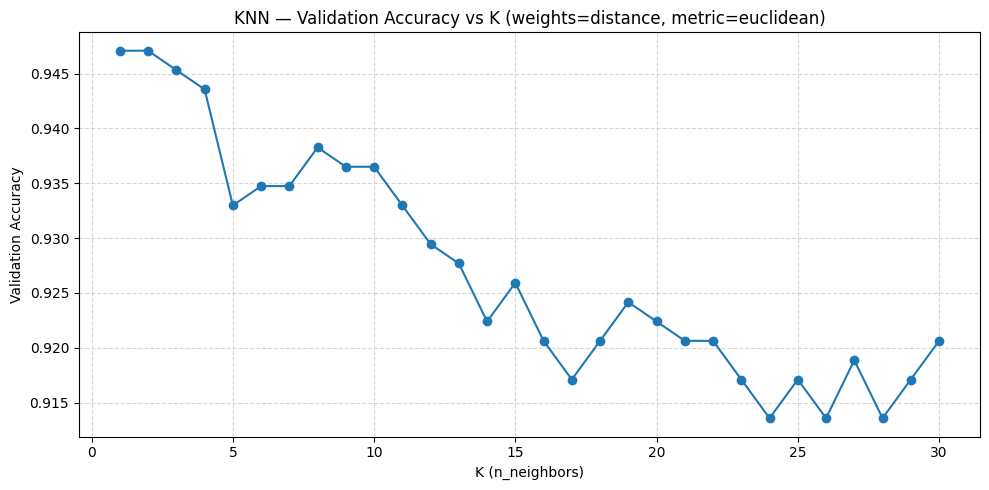

Best K from sweep: 1 (acc = 0.9471)


In [6]:
k_range = range(1, 31)
k_scores = []
for k in k_range:
    m = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
    m.fit(X_train, y_train)
    k_scores.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), k_scores, marker='o')
plt.title('KNN — Validation Accuracy vs K (weights=distance, metric=euclidean)')
plt.xlabel('K (n_neighbors)')
plt.ylabel('Validation Accuracy')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_k_sweep = k_range[int(np.argmax(k_scores))]
print(f"Best K from sweep: {best_k_sweep} (acc = {max(k_scores):.4f})")


## 4. Final Model Selection Leaderboard

Sorted by **Validation Accuracy** (descending), with the same column layout as the Excel leaderboard:
`Rank | Model | Best Hyperparameters | Accuracy | F1-Score | Note`.


In [7]:
ranked = results_df.sort_values('Validation Accuracy', ascending=False).reset_index(drop=True)

def note_for(rank, total):
    if rank == 0:
        return 'Top Performer'
    if rank == 1:
        return 'Strong Runner-up'
    if rank == total - 1:
        return 'Weak Baseline'
    return 'Acceptable'

leaderboard = pd.DataFrame({
    'Rank': range(1, len(ranked) + 1),
    'Model': ['KNN'] * len(ranked),
    'Best Hyperparameters': ranked.apply(
        lambda r: f"K={r['n_neighbors (K)']}, weights={r['Weights']}, metric={r['Metric']}", axis=1
    ),
    'Accuracy': ranked['Validation Accuracy'],
    'F1-Score': ranked['F1-Score'],
    'Note': [note_for(i, len(ranked)) for i in range(len(ranked))],
})

display(leaderboard)

best_exp_id = ranked.iloc[0]['Exp ID']
best_model  = trained_models[best_exp_id]
print(f"\nBest experiment: {best_exp_id}")
print(f"Hyperparameters: {leaderboard.iloc[0]['Best Hyperparameters']}")
print(f"Accuracy:        {leaderboard.iloc[0]['Accuracy']:.4f}")
print(f"F1-Score:        {leaderboard.iloc[0]['F1-Score']:.4f}")


,Rank,Model,Best Hyperparameters,Accuracy,F1-Score,Note
0,1,KNN,"K=7, weights=distance, metric=euclidean",0.9347,0.9396,Top Performer
1,2,KNN,"K=3, weights=uniform, metric=euclidean",0.9312,0.9351,Strong Runner-up
2,3,KNN,"K=11, weights=distance, metric=manhattan",0.9277,0.9335,Acceptable
3,4,KNN,"K=15, weights=distance, metric=minkowski",0.9259,0.9320,Acceptable
4,5,KNN,"K=5, weights=uniform, metric=euclidean",0.8677,0.8752,Weak Baseline



Best experiment: KNN_03
Hyperparameters: K=7, weights=distance, metric=euclidean
Accuracy:        0.9347
F1-Score:        0.9396


## 5. Best Model Analysis

Detailed evaluation of the top-ranked experiment from the leaderboard.


In [8]:
y_pred_best = best_model.predict(X_test)

print(f"Best Model: {best_exp_id}")
print(f"Accuracy:   {accuracy_score(y_test, y_pred_best):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_best))


Best Model: KNN_03
Accuracy:   0.9347

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93       274
           1       0.90      0.98      0.94       293

    accuracy                           0.93       567
   macro avg       0.94      0.93      0.93       567
weighted avg       0.94      0.93      0.93       567



### Confusion Matrix

- **True Negatives (Top-Left):** Correctly predicted negative cases.
- **False Positives (Top-Right):** Incorrectly predicted positive cases (Type I error).
- **False Negatives (Bottom-Left):** Incorrectly predicted negative cases (Type II error).
- **True Positives (Bottom-Right):** Correctly predicted positive cases.


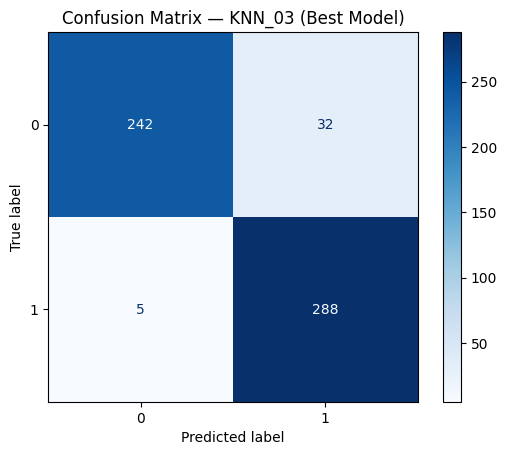

In [9]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix — {best_exp_id} (Best Model)')
plt.show()


### Permutation Feature Importance

KNN has no built-in coefficients, so feature importance is computed via **permutation importance** — shuffling each feature in turn and measuring the resulting drop in accuracy. Larger drops imply more important features.


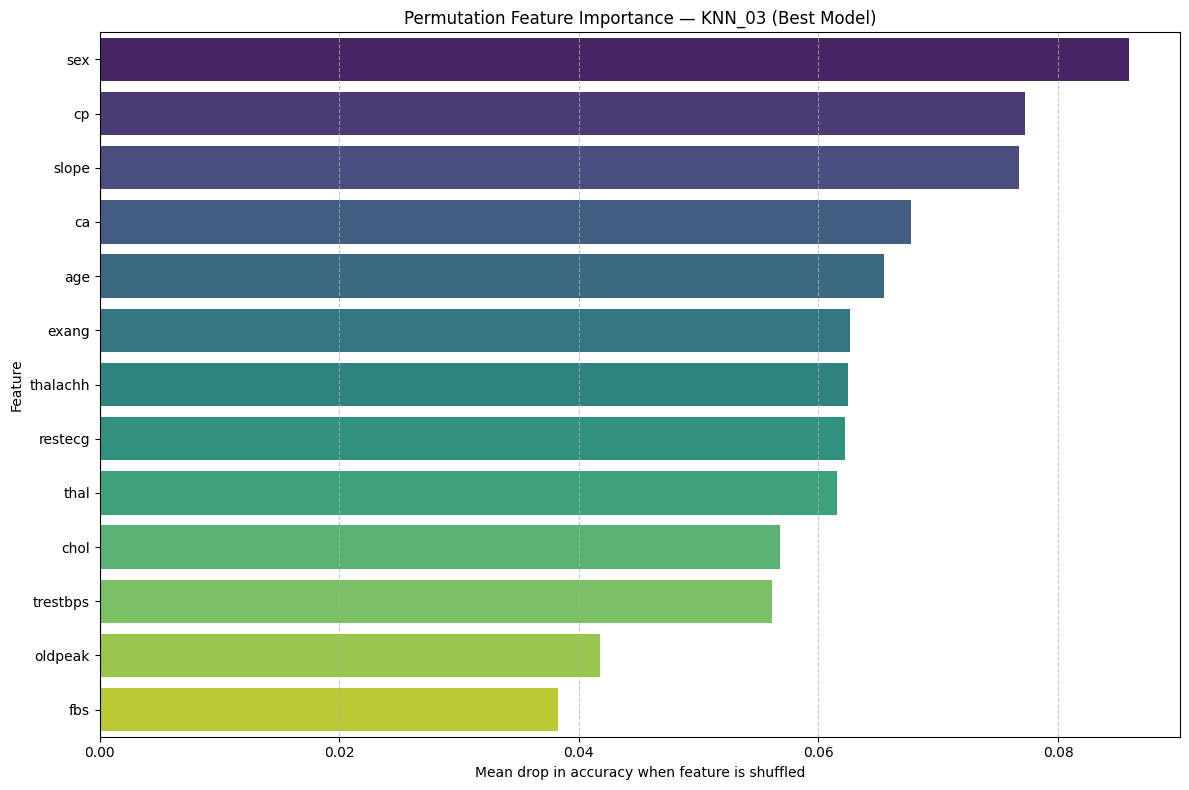

In [10]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=42, scoring='accuracy'
)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': perm.importances_mean,
    'std': perm.importances_std,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    x='importance', y='feature', data=feature_importance,
    palette='viridis', hue='feature', legend=False,
)
plt.title(f'Permutation Feature Importance — {best_exp_id} (Best Model)')
plt.xlabel('Mean drop in accuracy when feature is shuffled')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Conclusion

The KNN bake-off ran **5 experiments** (`KNN_01`–`KNN_05`) sweeping `n_neighbors`, `weights`, and `metric`. The hyperparameter tuning log captures each trial's validation accuracy alongside a status flag and qualitative insight, exactly as in the Excel template. The K-vs-accuracy elbow plot provides a complementary, finer-grained view of how K affects performance.

The **Final Model Selection Leaderboard** ranks the experiments end-to-end and identifies the top performer for downstream analysis. Confusion matrix and permutation feature-importance plots are then produced **only for the winning model**, keeping the analysis tightly coupled to the leaderboard's verdict.

This format scales naturally — adding a new model family (Logistic Regression, Random Forest, SVM, Gradient Boosting) is a matter of appending another tuning log section and merging the results into the same leaderboard, mirroring the four-model bake-off shown on the Titanic sheet.
